# **1. 손글씨 도형 분류하기**

손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True) # make directory

In [4]:
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall(extract_dir)

In [5]:
shape_root = extract_dir/'shape'
train_dir = shape_root/'train'
test_dir = shape_root/'test'
print('학습 경로:', train_dir)
print('테스트 경로:', test_dir)

학습 경로: data\shape\train
테스트 경로: data\shape\test


### ImageFolder
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서로 클래스 번호를 저장한다.

In [ ]:
# data/shape/train >> cir(0), tri(1), x(2)를 알파벳 순서로 label 저장
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)
print('클래스:', raw_train.classes)
print('클래스:', raw_train.class_to_idx)
print('학습 데이터 이미지 수: ', len(raw_train))
print('테스트 이미지 수: ', len(raw_test))

클래스: ['cir', 'tri', 'x']
클래스: {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수:  240
테스트 이미지 수:  60


# **2. 전처리와 데이터 증강**

- 모든 이미지를 28 x 28  1채널 흑백으로 통일
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖도록 함
- 픽셀 값을 텐서로 바꾼 뒤 평균 0.5, 표준편차 0.5로 정규화
- 학습 데이터에만 작은 회전/이동/크기 변화를 적용

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0), # 이미지 색상 반전
    transforms.RandomAffine(
        degrees=12,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
    # ToTensor()를 거쳐 0 ~ 1 사이로 바뀐 픽셀이 Nomalize()로 (값 - 0.5)/0.5 공식을 적용해 중앙값 0, 범위 -1 ~ 1로 조절하여 인공지능 모델이 더 빠르고 안정적으로 학습할 수 있게 함
])

# test
eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# **3. 학습/검증/테스트 데이터 분리**

- 학습 데이터: 가중치를 실제로 업데이트 함
- 검증 데이터: 학습 중 모델 선택과 과적합 확인
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤 최종 성능 확인

In [ ]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [ ]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist())
    val_indices.extend(indices[split:].tolist())

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터에서 원하는 데이터만 선택해서 새로운 데이터셋을 만듦
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)
print('학습: ', len(train_dataset))
print('검증: ', len(val_dataset))
print('테스트: ', len(test_dataset))

학습:  192
검증:  48
테스트:  60


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# **4. 이미지와 텐서 모양 확인**

- CNN 입력 텐서는 [배치, 채널 높이, 너비] 순서
- 위 데이터의 한 배치 shape는 [32, 1, 28, 28]


In [ ]:
images, labels = next(iter(train_loader))
print('이미지 배치:', images.shape)
print('레이블 배치:', labels.shape)

이미지 배치: torch.Size([32, 1, 28, 28])
레이블 배치: torch.Size([32])


In [ ]:
def denormalize(image): # 위에서 normalize 시킨 값은 visualization하기 어려움
    return image * 0.5 + 0.5

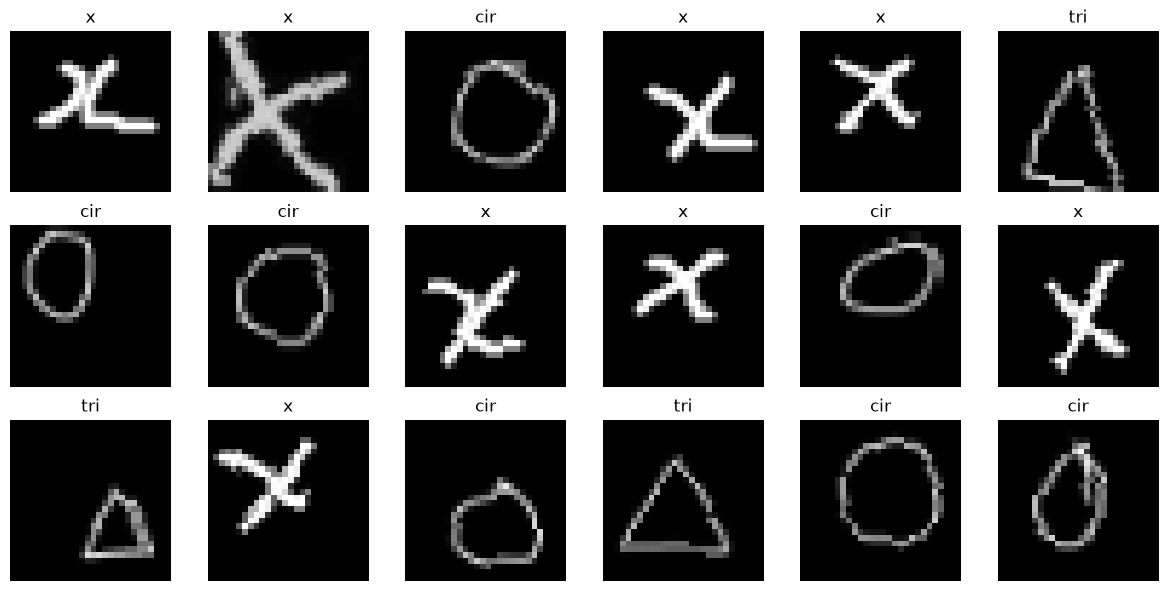

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1) # squeeze(0): [1, 28, 28] -> [28, 28]
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **5. CNN 모델**

### Feature Map의 증가
```
1 > 28 > 28 > MaxPool
28 > 56 > 56 > MaxPool
```
- 입력 이미지는 흑백 이미지이므로 처음에는 1개 채널
- 첫번째 합성곱층에서는 28개의 커널이 서로 다른 특징을 학습(예를 들어, 가로선, 세로선, 대각선, 곡선, 모서리, 원의 경계, 삼각형의 꼭짓점, x의 교차점과 같은 다양한 특징을 각각의 커널이 학습하게 됨)
    > 즉, 입력 이미지 한 장을 하나의 특징으로 보는 것이 아니라 28개의 서로 다른 특징맵으로 표현하게 됨
- 뒤로 갈수록 채널수가 증가하는 이유
    > 뒤쪽 레이어는 앞에서 학습한 특징들을 다시 조합하여 더 복잡한 특징을 찾음

### DropOut
- 학습할 때 일부 뉴런을 무작위로 비활성화하여 과적합을 방지하는 기법(예를 들어, 뉴런이 100개라면 약 25개는 사용하지 않고 약 75개만 이용하여 학습)
- 매 학습마다 비활성화되는 뉴런이 랜덤하게 달라지므로 특정 뉴런 하나에만 의존하지 않고 여러 특징을 함께 학습할 수 있게 됨

### nn.BatchNorm2d()
- 합성곱층의 출력값을 적절한 범위로 정규화하여 학습을 더 빠르고 안정적으로 만들어주는 층
```
채널1 출력: [5, 9, 8, 7] > 범위 5 ~ 9
채널2 출력: [120, 145, 243, 189] > 범위 120 ~ 243
채널3 출력: [-80, -63, -53, -72] > 범위 -80 ~ -53
...
채널32 출력: [1, 2, 30, 56] > 범위 1 ~ 56
```
- 커널마다 합성곱 연산에 따라 출력 범위가 다르기 때문에 레이어가 학습하기 어려움
>  nn.BatchNorm()은 각 채널마다 평균(0 부근), 분산(1 정도)을 계산하여 범위를 일정하게 만듦
    - 학습이 빨라짐(Loss가 더 빠르게 감소)
    - 값이 너무 커지는 또는, 작아지는 현상이 줄어듦

### nn.AdaptiveAvgPool2d()
- 입력 이미지의 크기가 얼마이든 상관없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어(예를들어, nn.AdaptiveAvgPool2d((1, 1))일때, 입력이 (64, 64), (32, 32)등에 상관없이 (1, 1)로 출력)
```
5 7 8
6 3 4 >> (5+7+8+6+3+4+1+2+9)/9 = 5
1 2 9
```
- CNN에서 분류 모델의 마지막 부분에 자주 사용
- CNN의 마지막에는 보통 128*7*7과 같은 Feature Map이 있는데, 이것을 Fully Connected Layer에 넣을려면 1차원으로 바꿔야 함 >> Flatten시켜 계산하는 것과 동일
- 파라미터가 줄기 때문에 계산량도 줄어들음
    - (128, 7, 7) >> linear(6272, 1000): 가중치 6,272,000개
    - nn.AdaptiveAvgPool2d() >> (128, 1, 1) >> linear(128, 1000): 가중치 128,000개 

In [ ]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False), # [32, 28, 28]
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), # 32개의 커널로 2회 진행하면 32개, 64개 커널로 각각 1번씩 하는 것보다 연산량도 줄고 학습결과도 좋음
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2), # [32, 14, 14]

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False), # [64, 14, 14]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2) # [64, 7, 7]
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, X):
        X = self.feature(X)
        return self.classifier(X)

### CUDA & NVIDIA 드라이버 확인
- 최신 드라이버와 CUDA Toolkit 설치 권장
- 드라이버 버전 확인
    - CUDA Version, 11.x 또는 12.x 사용
```
nvidia-smi
```

### Pytorch 설치(CUDA 지원)
- 공식 사이트에서 명령어 생성
- https://pytorch.org/get-started/locally/

In [ ]:
# 설치 확인
import torch

print(torch.__version__)              # 설치된 버전 확인
print(torch.cuda.is_available())      # True면 GPU 사용 가능
# print(torch.cuda.get_device_name(0))

2.13.0+cpu
False


In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else: 
    device = torch.device('cpu')

print(device)

cpu


In [ ]:
model = ShapeCNN(num_classes=num_classes).to(device)
model

ShapeCNN(
  (feature): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d

### Adam
- 학습률을 자동으로 조절해 주는 최적화 알고리즘

### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 과적합될 수 있음
- Weight Decay는 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
# 검증 성능이 더 이상 좋아지지 않을 떄 자동으로 학습률을 낮춰주는 Scheduler
# 학습 초반에는 빨리 내려가는 것이 좋음 > 후반부에는 거의 최적값 근처에 도착하기 떄문에 최적점을 지나치지 않기 위해 보폭을 줄여줌
# Epoch: Loss 0.80 > 0.66 > 0.50 > 0.43 > 0.40 > 0.40 > 0.40 << 0.40으로 최적점 형성
# mode='min': 무엇을 기준으로 좋은 모델을 판단할 지 결정
# factor=0.5: 학습률을 얼마나 줄일지 결정, 여기서는 절반으로 줄이도록 설정

### 학습과 평가 함수

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval() # is_training=True면 optimizer가 존재하므로 학습모드, is_training=False면 평가모드
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    context = torch.enable_grad() if is_training else torch.inference_mode() # enable_grad(): 기울기 계산을 활성화, inference_mode(): 메모리 사용량 감소, 실행속도 향상, 불필요한 기울기 계산 방지
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device, non_blocking=True) # cpu -> gpu
            if is_training:
                optimizer.zero_grad(set_to_none=True) # set_to_none=True: 기울기 값을 0으로 채우는 대신 None으로 설정하여 메모리 사용량 감소
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size
    return total_loss / total_samples, total_correct / total_samples

### 모델 학습과 Early Stopping
- 검증 손실이 가장 낮을 떄의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기 종료하여 과적합과 불필요한 학습을 줄임

In [ ]:
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8
OUTPUT_DIR = Path('outputs')
best_val_loss = float('inf')
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_path = OUTPUT_DIR / 'best_shape_cnn.pth'

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr'] # scheduler로 인해 학습률이 바뀌었는지 확인
    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
        f'lr {current_lr:.6f}'
    )
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= EARLY_STOPPING_PATIENCE:
            print('검증 손실이 더 이상 개선되지 않아 학습을 조기 종료합니다.')
            break


Epoch 01/40 | train loss 0.8001, acc  59.38% | val loss 1.0511, acc  35.42% | lr 0.001000
Epoch 02/40 | train loss 0.5656, acc  72.92% | val loss 0.8810, acc  64.58% | lr 0.001000
Epoch 03/40 | train loss 0.5395, acc  71.35% | val loss 0.7474, acc  68.75% | lr 0.001000
Epoch 04/40 | train loss 0.4696, acc  80.73% | val loss 0.6643, acc  79.17% | lr 0.001000
Epoch 05/40 | train loss 0.4643, acc  83.33% | val loss 0.6364, acc  81.25% | lr 0.001000
Epoch 06/40 | train loss 0.4362, acc  82.81% | val loss 0.5012, acc  83.33% | lr 0.001000
Epoch 07/40 | train loss 0.3774, acc  85.94% | val loss 0.5467, acc  85.42% | lr 0.001000
Epoch 08/40 | train loss 0.3560, acc  86.46% | val loss 0.3922, acc  87.50% | lr 0.001000
Epoch 09/40 | train loss 0.3819, acc  83.33% | val loss 0.4664, acc  75.00% | lr 0.001000
Epoch 10/40 | train loss 0.3197, acc  90.62% | val loss 0.4307, acc  70.83% | lr 0.001000
Epoch 11/40 | train loss 0.3101, acc  91.15% | val loss 0.4277, acc  77.08% | lr 0.001000
Epoch 12/4

### 학습 곡선으로 과적합 확인
- 학습 손실과 검증 손실이 함꼐 감소하면 정상적인 학습에 가까움
- 학습 손실은 계속 감소하지만 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터 품질을 검사해야 함

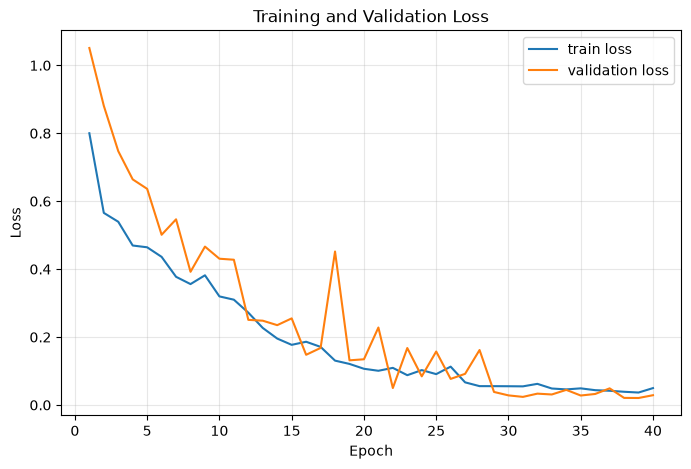

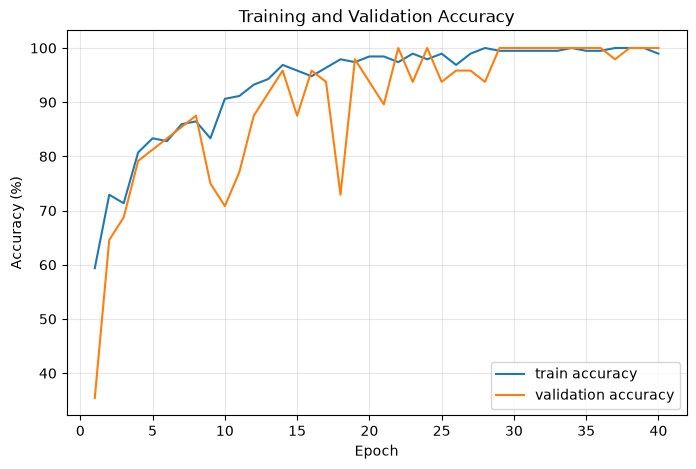

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 학습된 모델로 테스트 평가

In [ ]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 손실: 0.0329
테스트 정확도: 100.00%


### 가중치를 불러와 모델에 적용한 후 테스트 평가
- 나중에 model을 불러와 그대로 사용할려고 하면 메모리가 날라가 버리기 때문에 재사용시 가중치를 불러와 사용해야 함

In [ ]:
model = ShapeCNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

<All keys matched successfully>

In [ ]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 손실: 0.0689
테스트 정확도: 98.33%


In [ ]:
def collect_predictions(model, loader):
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(device))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

### 혼동행렬과 클래스별 성능
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻
- Precision: 해당 클래스로 예측한 것 중 실제로 맞은 비율
- Recall: 실제 해당 클래스 중 모델이 찾아낸 비율
- F1-score: Precision과 Recall의 조화평균

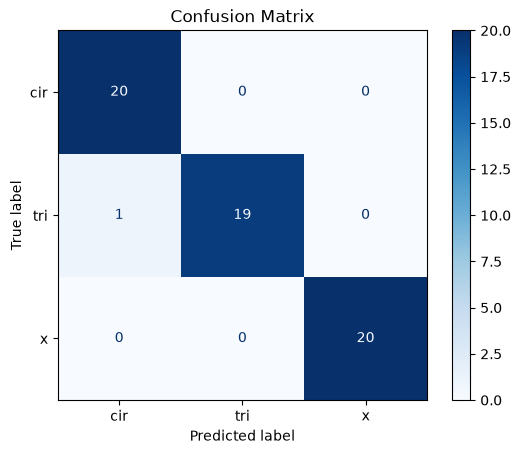

              precision    recall  f1-score   support

         cir     0.9524    1.0000    0.9756        20
         tri     1.0000    0.9500    0.9744        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         0.9833        60
   macro avg     0.9841    0.9833    0.9833        60
weighted avg     0.9841    0.9833    0.9833        60



In [ ]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

### 오분류 이미지 분석
- 모델이 틀린 이미지에는 데이터 품질, 모호한 필기, 전처리 문제, 부족한 학습 데이터 등 중요한 단서가 들어있음
- 단순히 정확도 숫자만 보는 것보다 오분류 사례를 직접 확인하는 것이 모델 개선에 중요

In [ ]:
wrong_indices = torch.where(y_true != y_pred)[0]
print('오분류 이미지 수:', len(wrong_indices))

오분류 이미지 수: 1


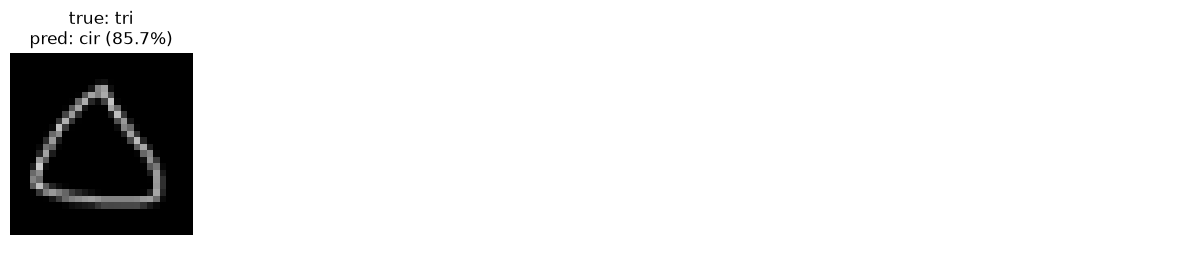

In [ ]:
if len(wrong_indices) == 0:
    print("오분류된 이미지가 없습니다.")
else:
    show_count = min(18, len(wrong_indices))
    selected = wrong_indices[:show_count]
    rows = int(np.ceil(show_count / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(12, 2.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected):
        true_idx = y_true[idx].item()
        pred_idx = y_pred[idx].item()
        confidence = y_prob[idx, pred_idx].item() * 100
        ax.imshow(denormalize(test_images[idx]).squeeze(0), cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'true: {class_names[true_idx]}\n'
            f'pred: {class_names[pred_idx]} ({confidence:.1f}%)'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 성능을 더 높일때 점검할 순서
1. 잘못된 레이블이나 지나치게 모호한 그림이 없는지 확인
2. 실제 사용 환경과 학습 데이터의 배경색/선 굵기/크기 차이를 줄임
3. 클래스별 데이터를 더 다양하게 수집
4. 증강 강도를 조금씩 바꿔며 검증 성능을 비교
5. 데이터가 충분히 늘어난 뒤 모델 크기와 학습률을 조절
> 이 데이터는 전체 300장으로 매우 작다. 테스트 정확도가 높더라도 실제 손글씨 전체를 대표한다고 단정할 수 없다. 새로운 사람이 그린 별도 데이터로 추가 검증해야 한다.